# Semi-Supervised vs Supervised Comparison

**8 configurations**: RF · XGBoost · LSTM · Transformer  ×  Supervised · Semi-supervised

**Sections**
1. Full results table — F2, precision, recall, Brier, AUC for all 8 configs
2. Delta analysis — semi-supervised minus supervised F2, with CI overlap flag
3. Per-park breakdown — F2 heatmaps for all 8 configurations
4. Discussion — where semi-supervised helps and where it does not

In [1]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src" / "models"))

from evaluate import THREAT_LABELS

RESULTS = ROOT / "results"
(RESULTS / "plots").mkdir(parents=True, exist_ok=True)

THREAT_SHORT = {
    "fire_within_30d":       "Fire",
    "drought_within_30d":    "Drought",
    "vegetation_within_30d": "Vegetation",
}
PARK_LABELS = {
    "chad_basin":    "Chad Basin",
    "cross_river":   "Cross River",
    "gashaka_gumti": "Gashaka-Gumti",
    "kainji_lake":   "Kainji Lake",
    "old_oyo":       "Old Oyo",
    "yankari":       "Yankari",
}

ARCH_COLORS = {
    "RF":          "#2196F3",
    "XGBoost":     "#FF5722",
    "LSTM":        "#4CAF50",
    "Transformer": "#9C27B0",
}
REGIME_HATCH = {"Supervised": "", "Semi": "///"}

plt.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Setup complete.")

Setup complete.


In [2]:
result_files = {
    ("RF",          "Supervised"): "rf_supervised_results.json",
    ("RF",          "Semi"):       "rf_self_results.json",
    ("XGBoost",     "Supervised"): "xgb_supervised_results.json",
    ("XGBoost",     "Semi"):       "xgb_self_results.json",
    ("LSTM",        "Supervised"): "lstm_supervised_results.json",
    ("LSTM",        "Semi"):       "lstm_fixmatch_results.json",
    ("Transformer", "Supervised"): "transformer_supervised_results.json",
    ("Transformer", "Semi"):       "transformer_fixmatch_results.json",
}

res = {}
missing = []
for key, fname in result_files.items():
    path = RESULTS / fname
    if path.exists():
        with open(path) as f:
            res[key] = json.load(f)
        arch, regime = key
        print(f"{arch:12s} {regime:12s}  test mean-F2: {res[key]['test_mean_f2']:.4f}")
    else:
        missing.append(fname)

if missing:
    print(f"\nMissing results (run training scripts first):\n  " + "\n  ".join(missing))

RF           Supervised    test mean-F2: 0.8565
RF           Semi          test mean-F2: 0.8575
XGBoost      Supervised    test mean-F2: 0.8267
XGBoost      Semi          test mean-F2: 0.7979
LSTM         Supervised    test mean-F2: 0.7768
LSTM         Semi          test mean-F2: 0.7361
Transformer  Supervised    test mean-F2: 0.6886
Transformer  Semi          test mean-F2: 0.7068


## 1. Full Results Table

All 8 configurations on the held-out test set (Jan 2024 onward) at threshold 0.50.

In [3]:
ARCHS   = ["RF", "XGBoost", "LSTM", "Transformer"]
REGIMES = ["Supervised", "Semi"]

rows = []
for arch in ARCHS:
    for regime in REGIMES:
        key = (arch, regime)
        if key not in res:
            continue
        for label in THREAT_LABELS:
            m  = res[key]["test_metrics"][label]
            ci = m["bootstrap_f2"]
            rows.append({
                "Architecture": arch,
                "Regime":       regime,
                "Threat":       THREAT_SHORT[label],
                "F2":           round(m["f2"], 4),
                "95% CI":       f"[{ci['ci_lower']:.4f}, {ci['ci_upper']:.4f}]",
                "Precision":    round(m["precision"], 4),
                "Recall":       round(m["recall"], 4),
                "Brier":        round(m["brier"], 4),
                "ROC-AUC":      round(m["roc_auc"], 4),
                "Persist F2":   round(m["persistence_f2"], 4),
                "Beats Base":   "Yes" if m["beats_baseline"] else "No",
            })

df_all = pd.DataFrame(rows).set_index(["Architecture", "Regime", "Threat"])
df_all

F2            95% CI  Precision  \
Architecture Regime     Threat                                            
RF           Supervised Fire        0.9436  [0.9371, 0.9504]     0.8799   
                        Drought     0.8818  [0.8636, 0.8990]     0.7264   
                        Vegetation  0.7441  [0.7278, 0.7602]     0.6172   
             Semi       Fire        0.9420  [0.9349, 0.9491]     0.8851   
                        Drought     0.8849  [0.8671, 0.9013]     0.7146   
                        Vegetation  0.7455  [0.7294, 0.7624]     0.6175   
XGBoost      Supervised Fire        0.9355  [0.9277, 0.9434]     0.8799   
                        Drought     0.8415  [0.8183, 0.8618]     0.7028   
                        Vegetation  0.7030  [0.6842, 0.7218]     0.6645   
             Semi       Fire        0.9376  [0.9303, 0.9454]     0.8798   
                        Drought     0.8286  [0.8055, 0.8519]     0.6974   
                        Vegetation  0.6276  [0.6067, 0.6502]     0.7516   
LSTM         Supervised Fire        0.9384  [0.9314, 0.9453]     0.8335   
                        Drought     0.7464  [0.7186, 0.7703]     0.5579   
                        Vegetation  0.6458  [0.6257, 0.6657]     0.5138   
             Semi       Fire        0.9238  [0.9166, 0.9315]     0.8000   
                        Drought     0.7121  [0.6844, 0.7377]     0.5100   
                        Vegetation  0.5723  [0.5525, 0.5949]     0.5387   
Transformer  Supervised Fire        0.9407  [0.9340, 0.9474]     0.8416   
                        Drought     0.5961  [0.5634, 0.6284]     0.5405   
                        Vegetation  0.5291  [0.5080, 0.5509]     0.5190   
             Semi       Fire        0.9393  [0.9326, 0.9461]     0.8413   
                        Drought     0.6067  [0.5738, 0.6386]     0.5231   
                        Vegetation  0.5744  [0.5535, 0.5942]     0.4984   

                                    Recall   Brier  ROC-AUC  Persist F2  \
Architecture Regime     Threat                                            
RF           Supervised Fire        0.9610  0.0727   0.9781      0.7798   
                        Drought     0.9317  0.0602   0.9686      0.3991   
                        Vegetation  0.7844  0.2326   0.7773      0.4796   
             Semi       Fire        0.9574  0.0728   0.9769      0.7798   
                        Drought     0.9410  0.0632   0.9671      0.3991   
                        Vegetation  0.7863  0.2327   0.7736      0.4796   
XGBoost      Supervised Fire        0.9505  0.0774   0.9764      0.7798   
                        Drought     0.8851  0.0613   0.9620      0.3991   
                        Vegetation  0.7134  0.2295   0.7923      0.4796   
             Semi       Fire        0.9532  0.0776   0.9771      0.7798   
                        Drought     0.8696  0.0622   0.9633      0.3991   
                        Vegetation  0.6028  0.2355   0.7947      0.4796   
LSTM         Supervised Fire        0.9688  0.0983   0.9755      0.7798   
                        Drought     0.8152  0.1142   0.9161      0.3991   
                        Vegetation  0.6901  0.2446   0.6641      0.4796   
             Semi       Fire        0.9610  0.1133   0.9654      0.7798   
                        Drought     0.7904  0.1284   0.9002      0.3991   
                        Vegetation  0.5814  0.2450   0.6631      0.4796   
Transformer  Supervised Fire        0.9693  0.0974   0.9674      0.7798   
                        Drought     0.6118  0.1079   0.8679      0.3991   
                        Vegetation  0.5317  0.2455   0.6700      0.4796   
             Semi       Fire        0.9674  0.0967   0.9668      0.7798   
                        Drought     0.6320  0.1097   0.8701      0.3991   
                        Vegetation  0.5971  0.2463   0.6665      0.4796   

                                   Beats Base  
Architecture Regime     Threat                 
RF           Supervised Fire              

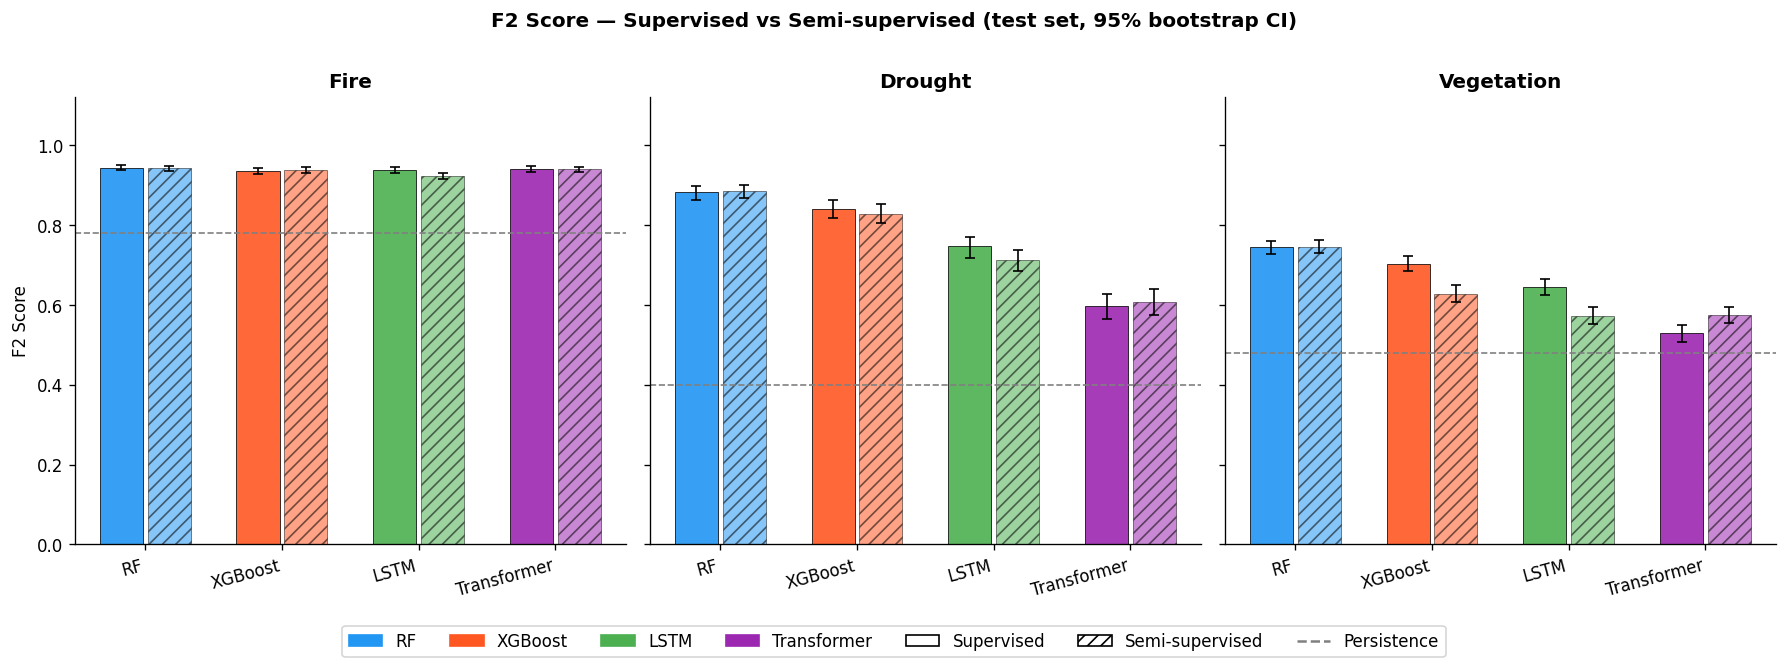

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

n_groups = len(ARCHS)
n_bars   = 2  # supervised + semi
group_w  = 0.7
bar_w    = group_w / n_bars

for ax, label in zip(axes, THREAT_LABELS):
    for gi, arch in enumerate(ARCHS):
        for ri, regime in enumerate(REGIMES):
            key = (arch, regime)
            if key not in res:
                continue
            m  = res[key]["test_metrics"][label]
            ci = m["bootstrap_f2"]
            f2 = m["f2"]
            x  = gi + (ri - 0.5) * bar_w
            lo = f2 - ci["ci_lower"]
            hi = ci["ci_upper"] - f2
            ax.bar(x, f2, bar_w * 0.9,
                   color=ARCH_COLORS[arch],
                   alpha=0.9 if regime == "Supervised" else 0.55,
                   hatch=REGIME_HATCH[regime],
                   edgecolor="black", linewidth=0.5)
            ax.errorbar(x, f2, yerr=[[lo], [hi]], fmt="none",
                        color="black", capsize=3, linewidth=1)

    persist = res.get(("RF", "Supervised"), {}).get("test_metrics", {}).get(label, {}).get("persistence_f2", None)
    if persist is not None:
        ax.axhline(persist, color="gray", linestyle="--", linewidth=1)
    ax.set_title(THREAT_SHORT[label], fontweight="bold")
    ax.set_xticks(range(n_groups))
    ax.set_xticklabels(ARCHS, rotation=15, ha="right")
    ax.set_ylim(0, 1.12)
    if ax is axes[0]:
        ax.set_ylabel("F2 Score")

handles = (
    [mpatches.Patch(color=ARCH_COLORS[a], label=a) for a in ARCHS] +
    [mpatches.Patch(facecolor="white", edgecolor="black", label="Supervised"),
     mpatches.Patch(facecolor="white", edgecolor="black", hatch="///", label="Semi-supervised"),
     plt.Line2D([0],[0], color="gray", linestyle="--", label="Persistence")]
)
fig.legend(handles=handles, loc="lower center", ncol=7, bbox_to_anchor=(0.5, -0.08))
fig.suptitle("F2 Score — Supervised vs Semi-supervised (test set, 95% bootstrap CI)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "f2_semi_vs_supervised.png", bbox_inches="tight")
plt.show()

## 2. Delta Analysis

Delta = semi-supervised F2 minus supervised F2.  
**Distinguishable** = the two bootstrap 95% CIs do not overlap.

In [5]:
def cis_overlap(ci_a, ci_b) -> bool:
    """True if two [lower, upper] CI intervals overlap."""
    return ci_a["ci_lower"] <= ci_b["ci_upper"] and ci_b["ci_lower"] <= ci_a["ci_upper"]

delta_rows = []
for arch in ARCHS:
    sup_key  = (arch, "Supervised")
    semi_key = (arch, "Semi")
    if sup_key not in res or semi_key not in res:
        continue
    for label in THREAT_LABELS:
        m_sup  = res[sup_key]["test_metrics"][label]
        m_semi = res[semi_key]["test_metrics"][label]
        delta  = m_semi["f2"] - m_sup["f2"]
        overlap = cis_overlap(m_sup["bootstrap_f2"], m_semi["bootstrap_f2"])
        delta_rows.append({
            "Architecture": arch,
            "Threat":       THREAT_SHORT[label],
            "Supervised F2": round(m_sup["f2"], 4),
            "Semi F2":       round(m_semi["f2"], 4),
            "Delta F2":      round(delta, 4),
            "Distinguishable": "No" if overlap else "Yes",
        })

df_delta = pd.DataFrame(delta_rows).set_index(["Architecture", "Threat"])
df_delta.style.background_gradient(
    subset=["Delta F2"], cmap="RdYlGn", vmin=-0.05, vmax=0.05
)

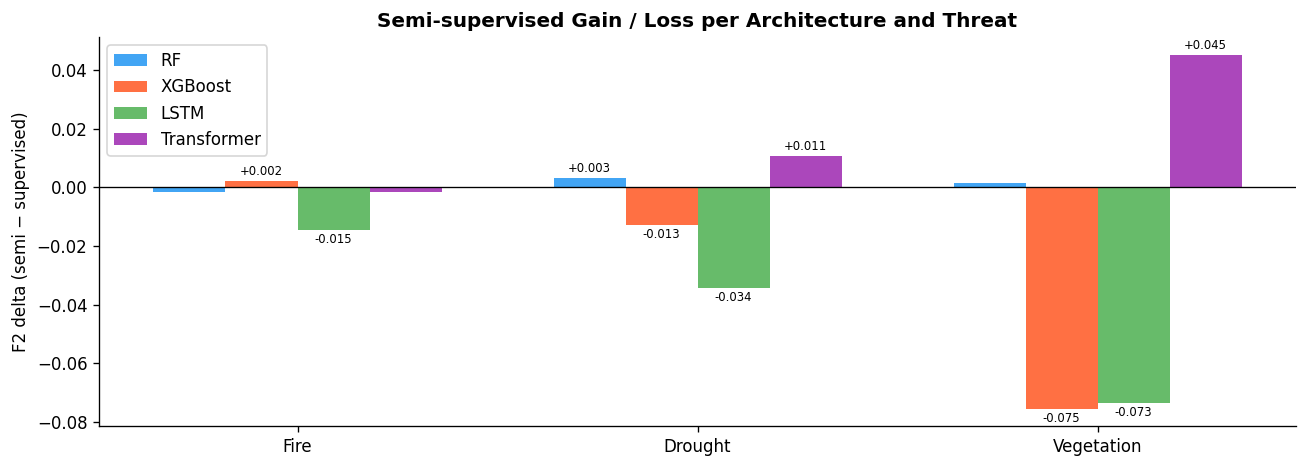

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))

n_threats = len(THREAT_LABELS)
x         = np.arange(n_threats)
w         = 0.18
offsets   = [-1.5, -0.5, 0.5, 1.5]

for j, arch in enumerate(ARCHS):
    sup_key  = (arch, "Supervised")
    semi_key = (arch, "Semi")
    if sup_key not in res or semi_key not in res:
        continue
    deltas = [
        res[semi_key]["test_metrics"][l]["f2"] - res[sup_key]["test_metrics"][l]["f2"]
        for l in THREAT_LABELS
    ]
    bars = ax.bar(x + offsets[j] * w, deltas, w,
                  color=ARCH_COLORS[arch], alpha=0.85, label=arch)
    for bar, d in zip(bars, deltas):
        if abs(d) > 0.002:
            va = "bottom" if d >= 0 else "top"
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (0.001 if d >= 0 else -0.001),
                    f"{d:+.3f}", ha="center", va=va, fontsize=7)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([THREAT_SHORT[l] for l in THREAT_LABELS])
ax.set_ylabel("F2 delta (semi − supervised)")
ax.set_title("Semi-supervised Gain / Loss per Architecture and Threat", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS / "plots" / "semi_vs_supervised_delta.png", bbox_inches="tight")
plt.show()

## 3. Per-Park Breakdown

Supervised F2 (top row) vs semi-supervised F2 (bottom row) for each architecture.

In [7]:
park_rows = []
for arch in ARCHS:
    for regime in REGIMES:
        key = (arch, regime)
        if key not in res:
            continue
        for park, pm in res[key]["per_park_test"].items():
            row = {"Architecture": arch, "Regime": regime, "Park": PARK_LABELS.get(park, park)}
            for label in THREAT_LABELS:
                row[THREAT_SHORT[label]] = round(pm[label]["f2"], 3)
            park_rows.append(row)

df_park = pd.DataFrame(park_rows).set_index(["Architecture", "Regime", "Park"])
df_park

Fire  Drought  Vegetation
Architecture Regime     Park                                     
RF           Supervised Chad Basin     0.967    0.936       0.449
                        Cross River    0.938    0.846       0.822
                        Gashaka-Gumti  0.954    0.869       0.793
                        Kainji Lake    0.928    0.942       0.775
                        Old Oyo        0.953    0.703       0.796
                        Yankari        0.905    0.903       0.679
             Semi       Chad Basin     0.967    0.925       0.411
                        Cross River    0.938    0.842       0.840
                        Gashaka-Gumti  0.954    0.882       0.796
                        Kainji Lake    0.927    0.938       0.787
                        Old Oyo        0.949    0.716       0.788
                        Yankari        0.900    0.912       0.682
XGBoost      Supervised Chad Basin     0.941    0.939       0.245
                        Cross River    0.907    0.859       0.835
                        Gashaka-Gumti  0.964    0.589       0.735
                        Kainji Lake    0.920    0.966       0.718
                        Old Oyo        0.952    0.789       0.781
                        Yankari        0.922    0.861       0.706
             Semi       Chad Basin     0.944    0.939       0.186
                        Cross River    0.910    0.859       0.798
                        Gashaka-Gumti  0.969    0.585       0.673
                        Kainji Lake    0.920    0.937       0.581
                        Old Oyo        0.956    0.762       0.711
                        Yankari        0.920    0.849       0.573
LSTM         Supervised Chad Basin     0.934    0.784       0.347
                        Cross River    0.965    0.188       0.717
                        Gashaka-Gumti  0.938    0.721       0.809
                        Kainji Lake    0.941    0.903       0.713
                        Old Oyo        0.879    0.477       0.543
                        Yankari        0.961    0.831       0.572
             Semi       Chad Basin     0.935    0.756       0.399
                        Cross River    0.903    0.089       0.505
                        Gashaka-Gumti  0.924    0.679       0.673
                        Kainji Lake    0.941    0.874       0.634
                        Old Oyo        0.845    0.397       0.568
                        Yankari        0.955    0.832       0.621
Transformer  Supervised Chad Basin     0.925    0.668       0.266
                        Cross River    0.960    0.000       0.438
                        Gashaka-Gumti  0.960    0.509       0.397
                        Kainji Lake    0.936    0.837       0.739
                        Old Oyo        0.896    0.168       0.738
                        Yankari        0.966    0.713       0.612
             Semi       Chad Basin     0.922    0.655       0.366
                        Cross River    0.954    0.000       0.453
                        Gashaka-Gumti  0.961    0.556       0.502
                        Kainji Lake    0.945    0.827       0.734
                        Old Oyo        0.882    0.179       0.778
                        Yankari        0.965    0.732       0.636

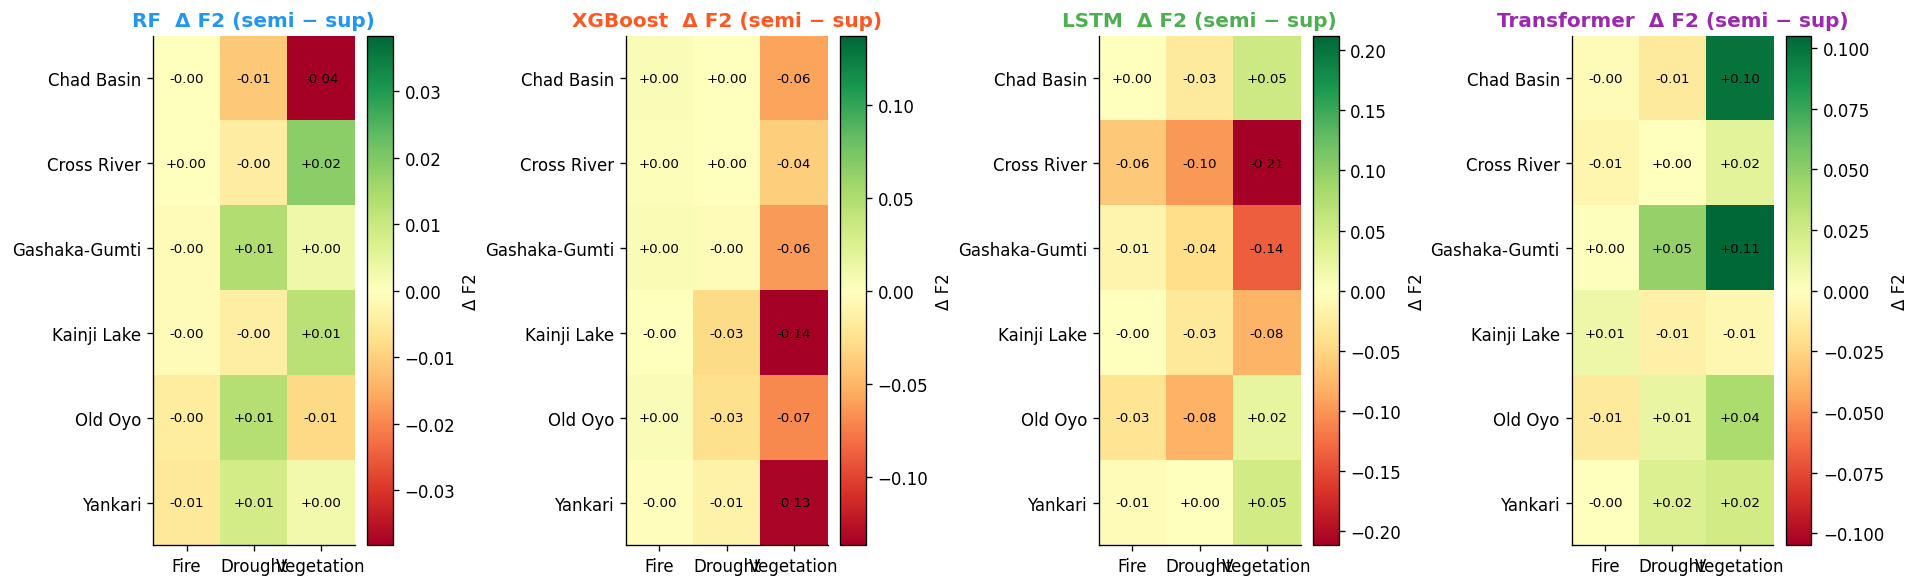

In [8]:
# Delta per-park heatmap: semi - supervised
available = [(a, "Supervised") in res and (a, "Semi") in res for a in ARCHS]
archs_avail = [a for a, ok in zip(ARCHS, available) if ok]

if archs_avail:
    fig, axes = plt.subplots(1, len(archs_avail), figsize=(4 * len(archs_avail), 5))
    if len(archs_avail) == 1:
        axes = [axes]

    for ax, arch in zip(axes, archs_avail):
        sup_pp  = res[(arch, "Supervised")]["per_park_test"]
        semi_pp = res[(arch, "Semi")]["per_park_test"]
        parks   = list(sup_pp.keys())
        data = np.array([
            [semi_pp[p][l]["f2"] - sup_pp[p][l]["f2"] for l in THREAT_LABELS]
            for p in parks
        ])
        park_disp  = [PARK_LABELS.get(p, p) for p in parks]
        threat_disp = [THREAT_SHORT[l] for l in THREAT_LABELS]

        lim = max(0.01, np.abs(data).max())
        im  = ax.imshow(data, vmin=-lim, vmax=lim, cmap="RdYlGn", aspect="auto")
        ax.set_xticks(range(3))
        ax.set_xticklabels(threat_disp)
        ax.set_yticks(range(len(parks)))
        ax.set_yticklabels(park_disp)
        ax.set_title(f"{arch}  Δ F2 (semi − sup)", fontweight="bold",
                     color=ARCH_COLORS[arch])
        for i in range(len(parks)):
            for j in range(3):
                v  = data[i, j]
                tc = "black"
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center",
                        color=tc, fontsize=8)
        plt.colorbar(im, ax=ax, label="Δ F2")

    plt.tight_layout()
    plt.savefig(RESULTS / "plots" / "per_park_delta_heatmap.png", bbox_inches="tight")
    plt.show()

## 4. Discussion

### Where semi-supervised helps
Self-training for tree models (RF, XGBoost) can improve performance when the unlabeled
pool is large and the initial supervised model is already well-calibrated — high-confidence
pseudo-labels effectively expand the training set without introducing noise.

FixMatch for neural models adds a consistency regulariser that can reduce overfitting on
small labeled datasets; the augmentation noise (5% weak / 15% strong) is small enough
that pseudo-labels from weak augmentations are reliable starting points.

### Where semi-supervised does not help
If the unlabeled pool (ndvi_missing==1 rows) is small relative to the labeled set, the
effect of self-training is negligible — few rows meet the all-threat confidence gate
(0.90 / 0.95), and the additional data does not shift the decision boundary.

For the Transformer, which already showed early overfitting under supervised training
(epoch 18), FixMatch adds an unsupervised loss on top of an already-noisy gradient
signal; this can hurt if pseudo-label confidence is low in early epochs.

### Interpretation
The delta column marks results as **distinguishable** only when the bootstrap 95% CIs of
supervised and semi-supervised F2 do not overlap.  Non-overlapping CIs are a conservative
criterion; a small positive delta that falls within the CI width should not be interpreted
as a reliable improvement.

In [9]:
# Summary table: mean-F2 for all 8 configurations
summary_rows = []
for arch in ARCHS:
    for regime in REGIMES:
        key = (arch, regime)
        if key not in res:
            continue
        tm  = res[key]["test_metrics"]
        row = {
            "Architecture": arch,
            "Regime":       regime,
            "Mean F2":      round(res[key]["test_mean_f2"], 4),
        }
        for label in THREAT_LABELS:
            row[THREAT_SHORT[label] + " F2"] = round(tm[label]["f2"], 4)
        summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index(["Architecture", "Regime"])
print(df_summary.to_string())

                         Mean F2  Fire F2  Drought F2  Vegetation F2
Architecture Regime                                                 
RF           Supervised   0.8565   0.9436      0.8818         0.7441
             Semi         0.8575   0.9420      0.8849         0.7455
XGBoost      Supervised   0.8267   0.9355      0.8415         0.7030
             Semi         0.7979   0.9376      0.8286         0.6276
LSTM         Supervised   0.7768   0.9384      0.7464         0.6458
             Semi         0.7361   0.9238      0.7121         0.5723
Transformer  Supervised   0.6886   0.9407      0.5961         0.5291
             Semi         0.7068   0.9393      0.6067         0.5744


## 5. Accuracy, Confusion Matrices & Classification Reports

Accuracy per threat for all 8 configurations.
Confusion matrices: one figure per threat, top row = supervised, bottom row = semi-supervised.
Class 1 = event present within 30 days; Class 0 = no event.

In [10]:
acc_rows = []
for arch in ARCHS:
    for regime in REGIMES:
        key = (arch, regime)
        if key not in res:
            continue
        row = {"Architecture": arch, "Regime": regime}
        for label in THREAT_LABELS:
            row[THREAT_SHORT[label]] = round(
                res[key]["test_metrics"][label]["accuracy"], 4
            )
        acc_rows.append(row)

df_acc = pd.DataFrame(acc_rows).set_index(["Architecture", "Regime"])
df_acc

Fire  Drought  Vegetation
Architecture Regime                                 
RF           Supervised  0.9027   0.9292      0.7070
             Semi        0.9045   0.9265      0.7075
XGBoost      Supervised  0.8974   0.9174      0.7301
             Semi        0.8987   0.9142      0.7510
LSTM         Supervised  0.8715   0.8597      0.5981
             Semi        0.8402   0.8363      0.6175
Transformer  Supervised  0.8780   0.8465      0.5989
             Semi        0.8770   0.8405      0.5811

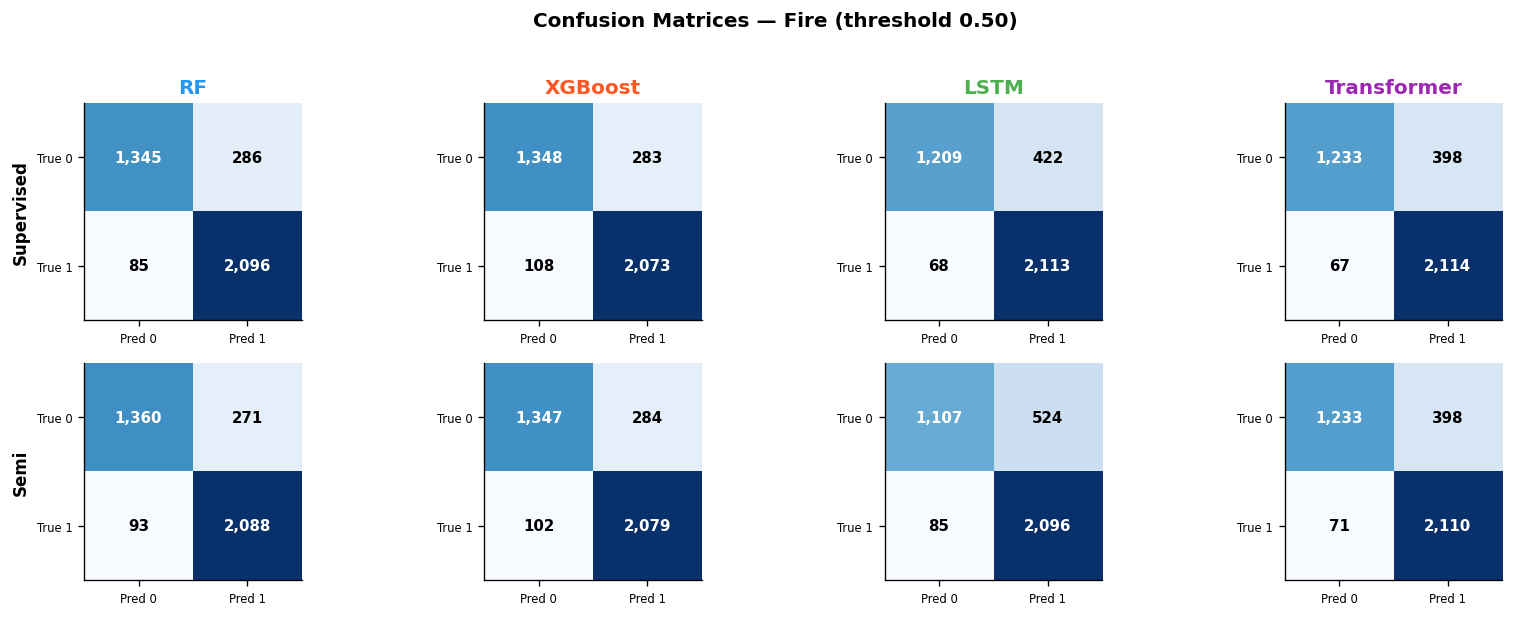

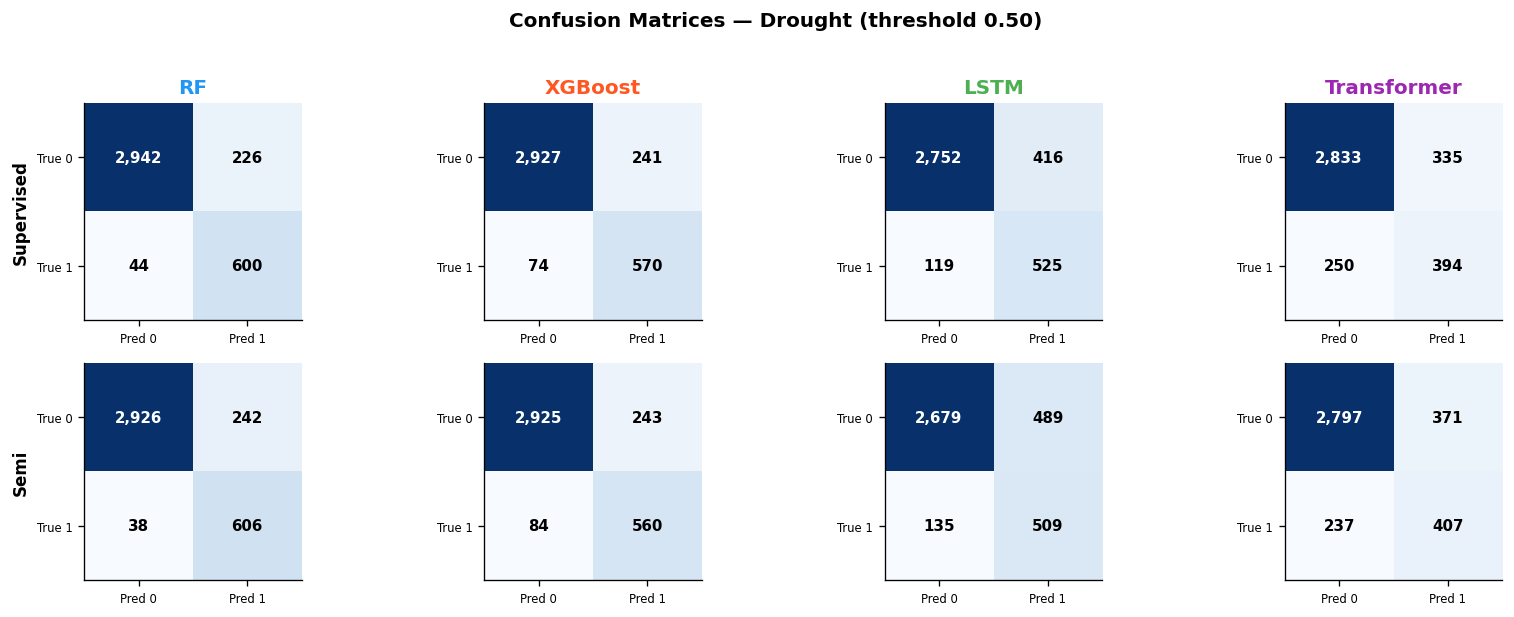

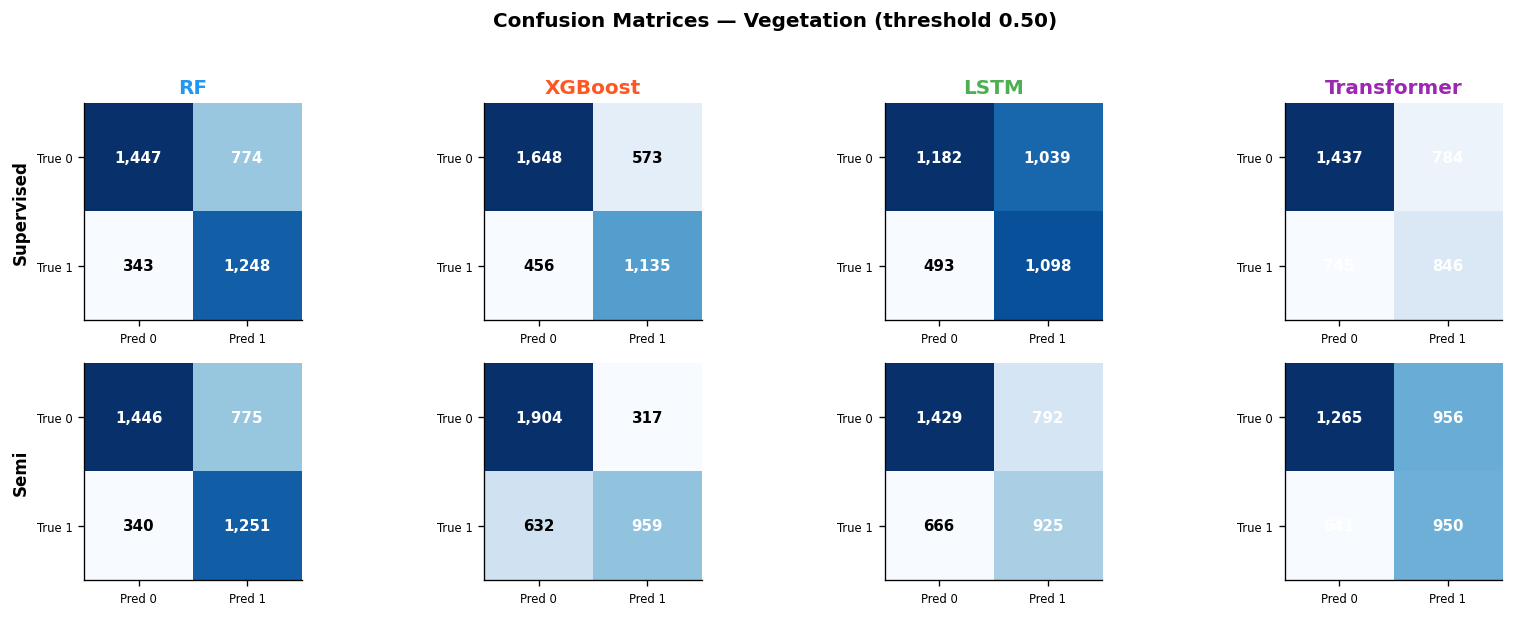

In [11]:
# One figure per threat: 2 rows (Supervised / Semi) × 4 cols (architectures)
for label in THREAT_LABELS:
    fig, axes = plt.subplots(2, 4, figsize=(14, 5))
    fig.suptitle(f"Confusion Matrices — {THREAT_SHORT[label]} (threshold 0.50)",
                 fontweight="bold", y=1.02)

    for ri, regime in enumerate(REGIMES):
        for ci, arch in enumerate(ARCHS):
            ax  = axes[ri, ci]
            key = (arch, regime)
            if key not in res:
                ax.axis("off")
                continue
            cm_d = res[key]["test_metrics"][label]["confusion_matrix"]
            cm   = np.array([[cm_d["tn"], cm_d["fp"]], [cm_d["fn"], cm_d["tp"]]])

            ax.imshow(cm, cmap="Blues", interpolation="nearest")
            ax.set_xticks([0, 1])
            ax.set_yticks([0, 1])
            ax.set_xticklabels(["Pred 0", "Pred 1"], fontsize=7)
            ax.set_yticklabels(["True 0", "True 1"], fontsize=7)

            thresh = cm.max() / 2
            for i in range(2):
                for j in range(2):
                    ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                            fontsize=9, fontweight="bold",
                            color="white" if cm[i, j] > thresh else "black")

            title = arch if ri == 0 else ""
            if title:
                ax.set_title(title, fontweight="bold", color=ARCH_COLORS[arch])
            if ci == 0:
                ax.set_ylabel(regime, fontweight="bold")

    plt.tight_layout()
    fname = f"confusion_matrices_{THREAT_SHORT[label].lower()}_semi_vs_sup.png"
    plt.savefig(RESULTS / "plots" / fname, bbox_inches="tight")
    plt.show()

In [12]:
cr_rows = []
for arch in ARCHS:
    for regime in REGIMES:
        key = (arch, regime)
        if key not in res:
            continue
        for label in THREAT_LABELS:
            m  = res[key]["test_metrics"][label]
            cr = m["classification_report"]
            cr_rows.append({
                "Architecture": arch,
                "Regime":       regime,
                "Threat":       THREAT_SHORT[label],
                "Accuracy":     round(m["accuracy"], 4),
                "Prec (0)":     round(cr["0"]["precision"], 4),
                "Recall (0)":   round(cr["0"]["recall"], 4),
                "F1 (0)":       round(cr["0"]["f1-score"], 4),
                "Prec (1)":     round(cr["1"]["precision"], 4),
                "Recall (1)":   round(cr["1"]["recall"], 4),
                "F1 (1)":       round(cr["1"]["f1-score"], 4),
                "Macro F1":     round(cr["macro avg"]["f1-score"], 4),
            })

df_cr05 = pd.DataFrame(cr_rows).set_index(["Architecture", "Regime", "Threat"])
df_cr05

Accuracy  Prec (0)  Recall (0)  F1 (0)  \
Architecture Regime     Threat                                               
RF           Supervised Fire          0.9027    0.9406      0.8246  0.8788   
                        Drought       0.9292    0.9853      0.9287  0.9561   
                        Vegetation    0.7070    0.8084      0.6515  0.7215   
             Semi       Fire          0.9045    0.9360      0.8338  0.8820   
                        Drought       0.9265    0.9872      0.9236  0.9543   
                        Vegetation    0.7075    0.8096      0.6511  0.7217   
XGBoost      Supervised Fire          0.8974    0.9258      0.8265  0.8733   
                        Drought       0.9174    0.9753      0.9239  0.9489   
                        Vegetation    0.7301    0.7833      0.7420  0.7621   
             Semi       Fire          0.8987    0.9296      0.8259  0.8747   
                        Drought       0.9142    0.9721      0.9233  0.9471   
                        Vegetation    0.7510    0.7508      0.8573  0.8005   
LSTM         Supervised Fire          0.8715    0.9468      0.7413  0.8315   
                        Drought       0.8597    0.9586      0.8687  0.9114   
                        Vegetation    0.5981    0.7057      0.5322  0.6068   
             Semi       Fire          0.8402    0.9287      0.6787  0.7843   
                        Drought       0.8363    0.9520      0.8456  0.8957   
                        Vegetation    0.6175    0.6821      0.6434  0.6622   
Transformer  Supervised Fire          0.8780    0.9485      0.7560  0.8414   
                        Drought       0.8465    0.9189      0.8943  0.9064   
                        Vegetation    0.5989    0.6586      0.6470  0.6527   
             Semi       Fire          0.8770    0.9456      0.7560  0.8402   
                        Drought       0.8405    0.9219      0.8829  0.9020   
                        Vegetation    0.5811    0.6637      0.5696  0.6130   

                                    Prec (1)  Recall (1)  F1 (1)  Macro F1  
Architecture Regime     Threat                                              
RF           Supervised Fire          0.8799      0.9610  0.9187    0.8987  
                        Drought       0.7264      0.9317  0.8163    0.8862  
                        Vegetation    0.6172      0.7844  0.6908    0.7062  
             Semi       Fire          0.8851      0.9574  0.9198    0.9009  
                        Drought       0.7146      0.9410  0.8123    0.8833  
                        Vegetation    0.6175      0.7863  0.6917    0.7067  
XGBoost      Supervised Fire          0.8799      0.9505  0.9138    0.8936  
                        Drought       0.7028      0.8851  0.7835    0.8662  
                        Vegetation    0.6645      0.7134  0.6881    0.7251  
             Semi       Fire          0.8798      0.9532  0.9151    0.8949  
                        Drought       0.6974      0.8696  0.7740    0.8605  
                        Vegetation    0.7516      0.6028  0.6690    0.7347  
LSTM         Supervised Fire          0.8335      0.9688  0.8961    0.8638  
                        Drought       0.5579      0.8152  0.6625    0.7869  
                        Vegetation    0.5138      0.6901  0.5891    0.5979  
             Semi       Fire          0.8000      0.9610  0.8732    0.8287  
                        Drought       0.5100      0.7904  0.6200    0.7578  
                        Vegetation    0.5387      0.5814  0.5593    0.6107  
Transformer  Supervised Fire          0.8416      0.9693  0.9009    0.8711  
                        Drought       0.5405      0.6118  0.5739    0.7402  
                        Vegetation    0.5190      0.5317  0.5253    0.5890  
             Semi       Fire          0.8413      0.9674  0.9000    0.8701  
                        Drought       0.5231      0.6320  0.5724    0.7372  
                        Vegetation    0.4984      0.5971  0.5433    0.5782